## 1. Importing Libraries 

In [46]:
import pandas as pd
import numpy as np
import sklearn

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score
from sklearn.model_selection import learning_curve

from xgboost import XGBRegressor

from feature_engine.datetime import DatetimeFeatures

import joblib
import matplotlib.pyplot as plt

## 2. Display Settings 

In [47]:
pd.set_option("display.max_columns", None)

In [48]:
sklearn.set_config(transform_output="pandas")

## 3. Getting the Data

In [49]:
train_df=pd.read_csv("data/train.csv")
val_df=pd.read_csv("data/val.csv")
test_df=pd.read_csv("data/test.csv")


In [50]:
train_df

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price
0,Multiple Carriers,2019-05-09,Delhi,Cochin,08:00:00,19:15:00,675,1.0,In-flight meal not included,9871
1,Air Asia,2019-05-06,Kolkata,Banglore,19:55:00,22:25:00,150,0.0,No Info,4409
2,Vistara,2019-06-15,Delhi,Cochin,14:40:00,17:50:00,190,0.0,No Info,6216
3,Air India,2019-05-09,Delhi,Cochin,19:45:00,19:15:00,1410,2.0,No Info,10178
4,Jet Airways,2019-06-06,Kolkata,Banglore,14:05:00,22:35:00,510,1.0,No Info,14571
...,...,...,...,...,...,...,...,...,...,...
635,Jet Airways,2019-06-06,Delhi,Cochin,19:30:00,12:35:00,1025,2.0,In-flight meal not included,11733
636,Spicejet,2019-06-09,Banglore,Delhi,21:10:00,00:05:00,175,0.0,No check-in baggage included,3919
637,Jet Airways,2019-06-21,Banglore,Delhi,18:55:00,22:00:00,185,0.0,No Info,8541
638,Indigo,2019-04-27,Banglore,Delhi,16:55:00,19:55:00,180,0.0,No Info,4823


### 3.1 Split the Data

In [51]:
def split_data(data):
    X=data.drop(columns="price")
    y=data.price.copy()
    return (X,y)

In [52]:
X_train, y_train=split_data(train_df)

In [53]:
X_train

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info
0,Multiple Carriers,2019-05-09,Delhi,Cochin,08:00:00,19:15:00,675,1.0,In-flight meal not included
1,Air Asia,2019-05-06,Kolkata,Banglore,19:55:00,22:25:00,150,0.0,No Info
2,Vistara,2019-06-15,Delhi,Cochin,14:40:00,17:50:00,190,0.0,No Info
3,Air India,2019-05-09,Delhi,Cochin,19:45:00,19:15:00,1410,2.0,No Info
4,Jet Airways,2019-06-06,Kolkata,Banglore,14:05:00,22:35:00,510,1.0,No Info
...,...,...,...,...,...,...,...,...,...
635,Jet Airways,2019-06-06,Delhi,Cochin,19:30:00,12:35:00,1025,2.0,In-flight meal not included
636,Spicejet,2019-06-09,Banglore,Delhi,21:10:00,00:05:00,175,0.0,No check-in baggage included
637,Jet Airways,2019-06-21,Banglore,Delhi,18:55:00,22:00:00,185,0.0,No Info
638,Indigo,2019-04-27,Banglore,Delhi,16:55:00,19:55:00,180,0.0,No Info


In [54]:
y_train

0       9871
1       4409
2       6216
3      10178
4      14571
       ...  
635    11733
636     3919
637     8541
638     4823
639    12389
Name: price, Length: 640, dtype: int64

In [55]:
X_val, y_val=split_data(val_df)
print(X_val.shape, y_val.shape)

(160, 9) (160,)


In [56]:
X_test, y_test=split_data(test_df)
print(X_test.shape, y_test.shape)

(200, 9) (200,)


### 3.2 Meta -info

In [57]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline          640 non-null    object 
 1   date_of_journey  640 non-null    object 
 2   source           640 non-null    object 
 3   destination      640 non-null    object 
 4   dep_time         640 non-null    object 
 5   arrival_time     640 non-null    object 
 6   duration         640 non-null    int64  
 7   total_stops      640 non-null    float64
 8   additional_info  640 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 45.1+ KB


## 4. Data Preprocessing 

In [58]:
dt_cols=["date_of_journey", "dep_time", "arrival_time"]

num_cols=["duration", "total_stops"]

cat_cols= [col for col in X_train.columns if (col not in dt_cols) and (col not in num_cols)]

In [59]:
cat_cols

['airline', 'source', 'destination', 'additional_info']

In [73]:
num_transformer=Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",StandardScaler() )
])

cat_transformer=Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore") )
    
])

doj_transformer=Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("extractor", DatetimeFeatures(features_to_extract=["hour", "minute"], format="mixed")),
     ("scaler",StandardScaler() )
])

time_transformer=Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("extractor", DatetimeFeatures(features_to_extract=["month", "week", "day_of_week", "day_of_month"], format="mixed")),
     ("scaler",StandardScaler() )
])

In [74]:
preprocessor =ColumnTransformer( transformers=[
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols),
    ("doj", doj_transformer, ["date_of_journey"]),
    ("time", time_transformer, ["dep_time", "arrival_time"]),
   
])

In [75]:
preprocessor.fit_transform(X_train)

C:\Users\vimal\AppData\Local\Programs\Python\Python310\lib\site-packages\feature_engine\variable_handling\_variable_type_checks.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  var = pd.to_datetime(column, utc=True)
C:\Users\vimal\AppData\Local\Programs\Python\Python310\lib\site-packages\feature_engine\variable_handling\_variable_type_checks.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  var = pd.to_datetime(column, utc=True)


,num__duration,num__total_stops,cat__airline_Air Asia,cat__airline_Air India,cat__airline_Goair,cat__airline_Indigo,cat__airline_Jet Airways,cat__airline_Multiple Carriers,cat__airline_Spicejet,cat__airline_Vistara,cat__source_Banglore,cat__source_Chennai,cat__source_Delhi,cat__source_Kolkata,cat__source_Mumbai,cat__destination_Banglore,cat__destination_Cochin,cat__destination_Delhi,cat__destination_Hyderabad,cat__destination_Kolkata,cat__destination_New Delhi,cat__additional_info_1 Long layover,cat__additional_info_In-flight meal not included,cat__additional_info_No Info,cat__additional_info_No check-in baggage included,doj__date_of_journey_hour,doj__date_of_journey_minute,time__dep_time_month,time__dep_time_week,time__dep_time_day_of_week,time__dep_time_day_of_month,time__arrival_time_month,time__arrival_time_week,time__arrival_time_day_of_week,time__arrival_time_day_of_month
0,0.108611,0.314339,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.950085,-1.186983,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.869423,-1.186983,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.590785,1.815661,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.224122,0.314339,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,0.814408,1.815661,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
636,-0.899671,-1.186983,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
637,-0.879505,-1.186983,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
638,-0.889588,-1.186983,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Model Selection

In [76]:
algorithms={
    "Linear Regression":LinearRegression(),
    "Support Vector Machine": SVR(),
    "Random Forest": RandomForestRegressor(n_estimators=10),
    "XG Boost": XGBRegressor(n_estimators=10)
}
    

In [77]:
data=pd.concat([train_df, val_df], axis=0)
X_data, y_data=split_data(data)
print(X_data.shape, y_data.shape)

(800, 9) (800,)


In [78]:
def plot_curves(sizes, mean_scores, std_scores, label, ax):
    ax.plot(
        sizes,
        mean_scores,
        marker="o",
        label=label
    )
    ax.fill_between(
        x=sizes,
        y1=mean_scores-std_scores,
        y2=mean_scores+std_scores,
        alpha=0.5
    ) 

In [131]:
def plot_learning_curves(name, algorithm, figsize=(12,4) ):
    model= Pipeline(steps=[
        ("pre", preprocessor),
        ("alg", algorithm)
    ])
    train_sizes, train_scores, test_scores=learning_curve(
        estimator=model,
        X=X_data,
        y=y_data,
        cv=3,
        scoring="r2",
        n_jobs=-1,
        random_state=42
    )
    mean_train_scores=np.mean(train_scores, axis=1)
    std_train_scores=np.std(train_scores, axis=1)
    train_score=f"{mean_train_scores[-1]:.2f}+/-{std_train_scores[-1]:.2f}"
    
    mean_test_scores=np.mean(test_scores, axis=1)
    std_test_scores=np.std(test_scores, axis=1)
    test_score=f"{mean_test_scores[-1]:.2f}+/-{std_test_scores[-1]:.2f}"

    
    fig, ax=plt.subplots(figsize=figsize)

    
    # training curve
    plot_curves(
        train_sizes,
        mean_train_scores,
        std_train_scores,
        f"Train ({train_score})",
        ax
    )

   # test curve
    plot_curves(
        train_sizes,
        mean_test_scores,
        std_test_scores,
        f"Test ({test_score})",
        ax
    )

    ax.set(xlabel="Training Set Size", ylabel="R-Square", title=name)

    ax.legend(loc="lower right")

    plt.show()




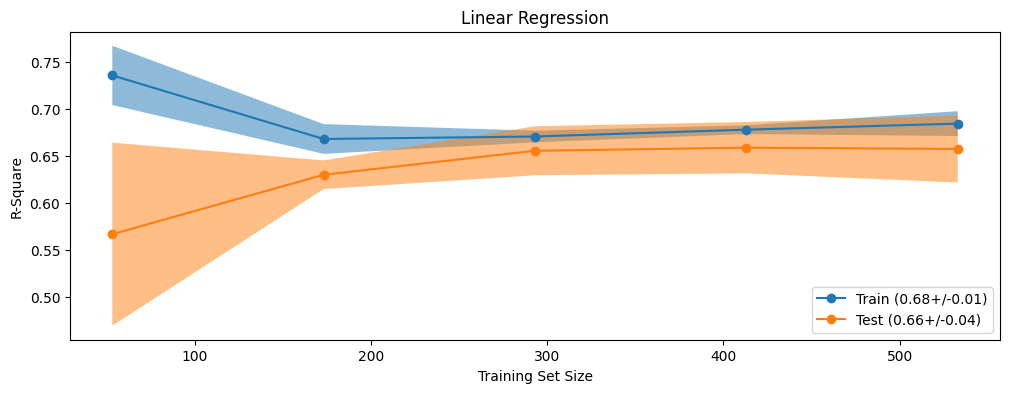

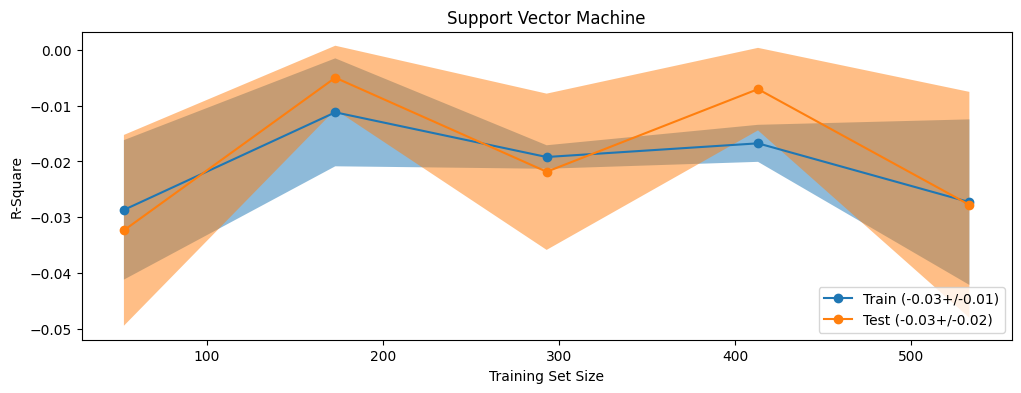

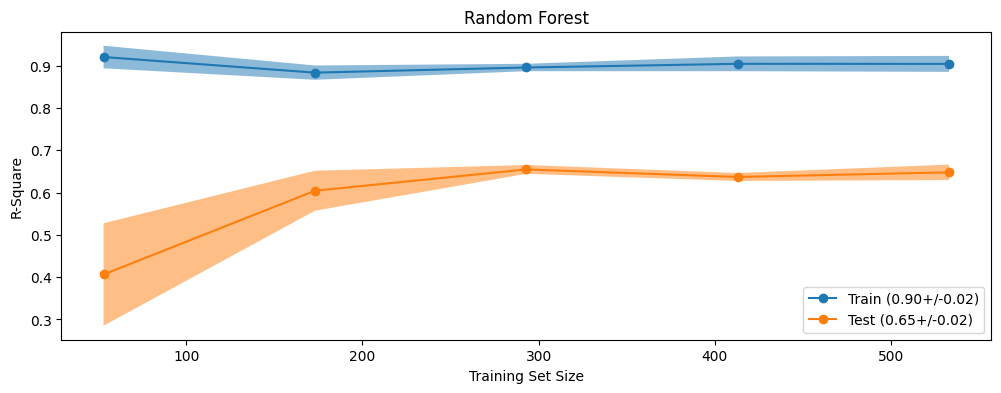

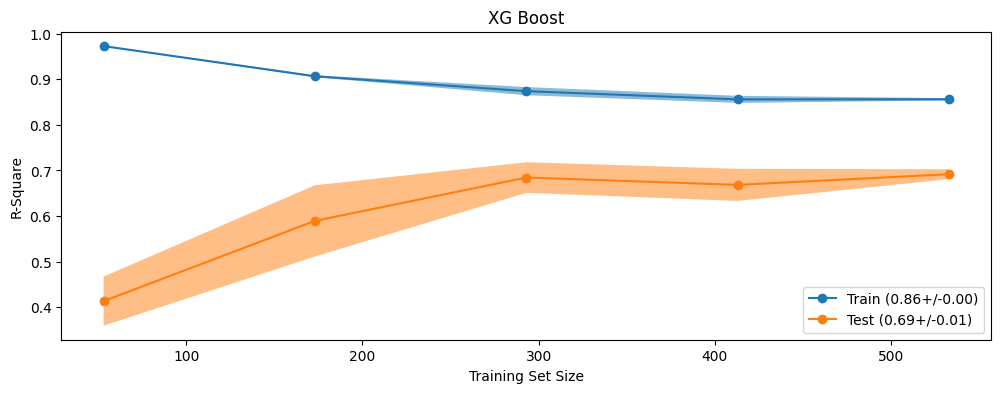

In [132]:
for name, alg in algorithms.items():
    plot_learning_curves(name,alg)

## 6.Model Training

In [126]:
model=Pipeline(steps=[
    ("pre", preprocessor),
    ("XG Boost", XGBRegressor(n_estimators=10))
])

In [127]:
model.fit(X_data,y_data)

C:\Users\vimal\AppData\Local\Programs\Python\Python310\lib\site-packages\feature_engine\variable_handling\_variable_type_checks.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  var = pd.to_datetime(column, utc=True)
C:\Users\vimal\AppData\Local\Programs\Python\Python310\lib\site-packages\feature_engine\variable_handling\_variable_type_checks.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  var = pd.to_datetime(column, utc=True)


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['duration', 'total_stops']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['airline', 'source',
                                                   '...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=10, n_jobs=None,
                              num_parallel_tree=None, ...))])

## 7. Model Evaluation

In [128]:
def evaluate_model(X,y):
    y_pred=model.predict(X)
    return r2_score(y,y_pred)

In [129]:
print(f"R2 score on Training data is = {evaluate_model(X_data, y_data)}")

R2 score on Training data is = 0.8331513086474105


In [130]:
print(f"R2 score on Test data is = {evaluate_model(X_test, y_test)}")

R2 score on Test data is = 0.6323864723050121


## 8. Model Persistence

In [134]:
joblib.dump(model, "model.joblib")


['model.joblib']

In [135]:
saved_model=joblib.load("model.joblib")
saved_model

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['duration', 'total_stops']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['airline', 'source',
                                                   '...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=10, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [136]:
# Ensure save m fine
y_pred=saved_model.predict(X_test)
r2_score(y_test, y_pred)

0.6323864723050121